In [6]:
import importlib.util
import json
import re
import tempfile
import warnings
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler

sys.path.insert(0, str(Path.cwd().parent / "code"))

from utils import *

import reservoirpy as rpy
from reservoirpy.hyper import parallel_research, plot_hyperopt_report

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="sklearn.base",
)

## Load data

In [7]:
# Load files

movie_name = "AfterTheRain"
target_column = "Throat"
data_root = Path("../data/emofilm")
behav_data = pd.read_csv(data_root / f"Annot_{movie_name}_stim.csv")

# Parcellated time series
timeseries_archive_path = data_root / f"{movie_name}_parcellated_timeseries.npz"

X = np.load(data_root / f"{movie_name}_schaefer200_parcellated_timeseries.npz")
X = [X[f'arr_{i}'] for i in range(len(X.files))]

# Behavioral data for prediction
event_timing_dir = data_root / "event_timings"
event_timing_files = sorted(event_timing_dir.glob(f"sub-*_{movie_name}_events.tsv"))
if len(X) != len(event_timing_files):
    raise ValueError(
        f"Timeseries count ({len(X)}) does not match event timing files ({len(event_timing_files)})."
    )


## Define hyperparameters for optimization

In [8]:
lag_seconds = 5.0
outer_n_splits = 5
inner_n_splits = 3
cv_random_state = 42
show_hyperopt_plots = False
reservoir_workers = 1
warmup = 20
hyperopt_search_dir = Path("../hyperopt-search")
hyperopt_plot_figsize = (24, 16)
hyperopt_plot_dpi = 100
hyperopt_report_prefix = "hyper-search-report"

hyper_search_config = {
    "exp": f"{movie_name}_{target_column}_nestedcv",
    "hp_max_evals": 200,
    "hp_method": "random",
    "seed": 42,
    "instances_per_trial": 3,
    "hp_space": {
        "N": ["choice", 300, 500],
        "sr": ["loguniform", 1e-2, 1e1],
        "lr": ["loguniform", 1e-3, 1],
        "input_scaling": ["loguniform", 1e-1, 1e1],
        "ridge": ["loguniform", 1e-9, 1e3],
        "seed": ["choice", 1234],
    },
}

helpers_path = Path("../test-predict-random-optim-HP.py").resolve()
helpers_spec = importlib.util.spec_from_file_location("brainhack_reservoir_helpers", helpers_path)
if helpers_spec is None or helpers_spec.loader is None:
    raise ImportError(f"Could not load helper script from {helpers_path}")
helpers = importlib.util.module_from_spec(helpers_spec)
helpers_spec.loader.exec_module(helpers)

prepare_hyperopt_run = helpers.prepare_hyperopt_run
move_hyperopt_results_to_run_dir = helpers.move_hyperopt_results_to_run_dir
build_flat_hyperopt_report_dir = helpers.build_flat_hyperopt_report_dir
build_esn = helpers.build_esn
build_final_esn_with_ridgecv = helpers.build_final_esn_with_ridgecv
predict_test_series = helpers.predict_test_series
compute_metrics = helpers.compute_metrics
RESULT_CALL_RE = helpers.RESULT_CALL_RE

In [9]:
if target_column not in behav_data.columns:
    raise ValueError(f"{target_column!r} not found in behav_data columns: {list(behav_data.columns)}")

movie_behavior = (
    behav_data[target_column]
    .astype(float)
    .interpolate(limit_direction="both")
    .bfill()
    .ffill()
    .to_numpy()
)
movie_target_length = len(movie_behavior)
y_true_single = movie_behavior[1:]
y_baseline_single = movie_behavior[:-1]

x_aligned = [
    align_fmri_to_movie_window(series, timing_file, movie_target_length, lag_seconds=lag_seconds)
    for series, timing_file in zip(X, event_timing_files)
]
subject_ids = np.arange(len(x_aligned))

if len(subject_ids) < 2:
    raise ValueError("Need at least two subjects for nested CV.")

x_all = [series[:-1] for series in x_aligned]
y_all = [y_true_single.reshape(-1, 1) for _ in x_aligned]
y_baseline_all = [y_baseline_single.reshape(-1, 1) for _ in x_aligned]
outer_cv = KFold(n_splits=min(outer_n_splits, len(subject_ids)), shuffle=True, random_state=cv_random_state)
outer_fold_results = []

## Nested cross validation for hyperparameter selection

In [ ]:
print(f"Using nested subject-wise CV with {outer_cv.get_n_splits()} outer folds.")
print()

for outer_fold_index, (train_index, test_index) in enumerate(outer_cv.split(subject_ids), start=1):
    train_subject_ids = subject_ids[train_index]
    test_subject_ids = subject_ids[test_index]

    x_train_outer = [x_all[i] for i in train_subject_ids]
    y_train_outer = [y_all[i] for i in train_subject_ids]
    x_test_outer = [x_all[i] for i in test_subject_ids]
    y_baseline_outer = [y_baseline_all[i] for i in test_subject_ids]

    x_scaler = MinMaxScaler(feature_range=(-1, 1))
    x_scaler.fit(np.vstack(x_train_outer))
    x_train_scaled_all = [x_scaler.transform(x) for x in x_train_outer]
    x_test_scaled_outer = [x_scaler.transform(x) for x in x_test_outer]

    y_scaler = MinMaxScaler(feature_range=(-1, 1))
    y_scaler.fit(np.vstack(y_train_outer))
    y_train_scaled_all = [y_scaler.transform(y) for y in y_train_outer]

    y_true_outer_flat = np.hstack([y_true_single for _ in test_subject_ids])
    y_baseline_outer_flat = np.hstack([y_baseline_single for _ in test_subject_ids])

    inner_cv = KFold(
        n_splits=min(inner_n_splits, len(train_subject_ids)),
        shuffle=True,
        random_state=cv_random_state + outer_fold_index,
    )
    inner_splits = list(inner_cv.split(np.arange(len(train_subject_ids))))

    fold_base_config = dict(hyper_search_config)
    fold_base_config["exp"] = f"{movie_name}_{target_column}_outerfold{outer_fold_index:02d}"
    hyperopt_config, fold_experiment_dir = prepare_hyperopt_run(fold_base_config)
    fold_experiment_dir = fold_experiment_dir / f"outer_fold_{outer_fold_index:02d}"
    fold_experiment_dir.mkdir(parents=True, exist_ok=False)
    config_path = fold_experiment_dir / f"{hyperopt_config['exp']}.config.json"
    with open(config_path, "w", encoding="utf-8") as f:
        json.dump(hyperopt_config, f, indent=2)

    dataset = {
        "X_train_scaled_all": x_train_scaled_all,
        "Y_train_scaled_all": y_train_scaled_all,
        "Y_true_flat": y_true_outer_flat,
        "y_scaler": y_scaler,
        "y_true_single": y_true_single,
        "y_baseline_single": y_baseline_single,
        "inner_splits": inner_splits,
        "warmup": warmup,
        "workers": reservoir_workers,
    }

    np.random.seed(hyperopt_config["seed"])
    rpy.set_seed(hyperopt_config["seed"])

    print(f"Outer fold {outer_fold_index}/{outer_cv.get_n_splits()}")
    print(f"Train subjects: {train_subject_ids.tolist()}")
    print(f"Test subjects : {test_subject_ids.tolist()}")
    print(f"Run folder: {fold_experiment_dir}")
    print()

    ## This is not working !
    best_params, best_loss = parallel_research(
        objective,
        dataset,
        config_path,
        fold_experiment_dir,
        helpers, build_esn, predict_test_series
    )
    move_hyperopt_results_to_run_dir(fold_experiment_dir)

    best_params = {
        "N": int(best_params["N"]),
        "sr": float(best_params["sr"]),
        "lr": float(best_params["lr"]),
        "input_scaling": float(best_params["input_scaling"]),
        "ridge": float(best_params["ridge"]),
        "seed": int(best_params["seed"]),
    }

    alphas = np.logspace(-9, 3, 13)
    final_esn, final_readout = build_final_esn_with_ridgecv(**best_params, alphas=alphas)
    final_esn.fit(
        x_train_scaled_all,
        y_train_scaled_all,
        warmup=warmup,
        workers=reservoir_workers,
    )
    final_predictions = predict_test_series(final_esn, x_test_scaled_outer, y_scaler)
    final_metrics = compute_metrics(helpers,y_true_outer_flat, final_predictions, y_baseline_outer_flat)

    outer_fold_results.append({
        "fold": outer_fold_index,
        "train_subjects": train_subject_ids.tolist(),
        "test_subjects": test_subject_ids.tolist(),
        "best_loss": float(best_loss),
        "best_params": best_params,
        "metrics": final_metrics,
        "alpha_selected": float(final_readout.instances.alpha_),
    })

    print(f"Best inner-CV RMSE: {best_loss:.6f}")
    print(f"Outer test RMSE  : {final_metrics['rmse']:.6f}")
    print(f"Outer test Corr  : {final_metrics['corr']:.6f}")
    print(f"Baseline RMSE    : {final_metrics['rmse_baseline']:.6f}")
    print(f"Baseline Corr    : {final_metrics['corr_baseline']:.6f}")
    print(f"Alpha selected by final RidgeCV: {final_readout.instances.alpha_:.1e}")
    print("-" * 80)

outer_summary = pd.json_normalize(outer_fold_results)
summary_table = outer_summary[[
    "metrics.rmse",
    "metrics.srmse",
    "metrics.corr",
    "metrics.rmse_baseline",
    "metrics.srmse_baseline",
    "metrics.corr_baseline",
    "metrics.rmse_ratio",
]].rename(columns={
    "metrics.rmse": "rmse",
    "metrics.srmse": "srmse",
    "metrics.corr": "corr",
    "metrics.rmse_baseline": "rmse_baseline",
    "metrics.srmse_baseline": "srmse_baseline",
    "metrics.corr_baseline": "corr_baseline",
    "metrics.rmse_ratio": "rmse_ratio",
})

print()
print("Nested subject-wise CV summary")
print(summary_table.mean().to_string())
print()
print("Fold-wise results")
print(outer_summary.to_string(index=False))

Using nested subject-wise CV with 5 outer folds.

Outer fold 1/5
Train subjects: [1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 14, 16, 18, 19, 20, 21, 22]
Test subjects : [0, 8, 9, 15, 17]
Run folder: hyperopt-search/AfterTheRain_Throat_outerfold01_2026-06-13_12h59b/outer_fold_01



TypeError: int() argument must be a string, a bytes-like object or a real number, not 'module'

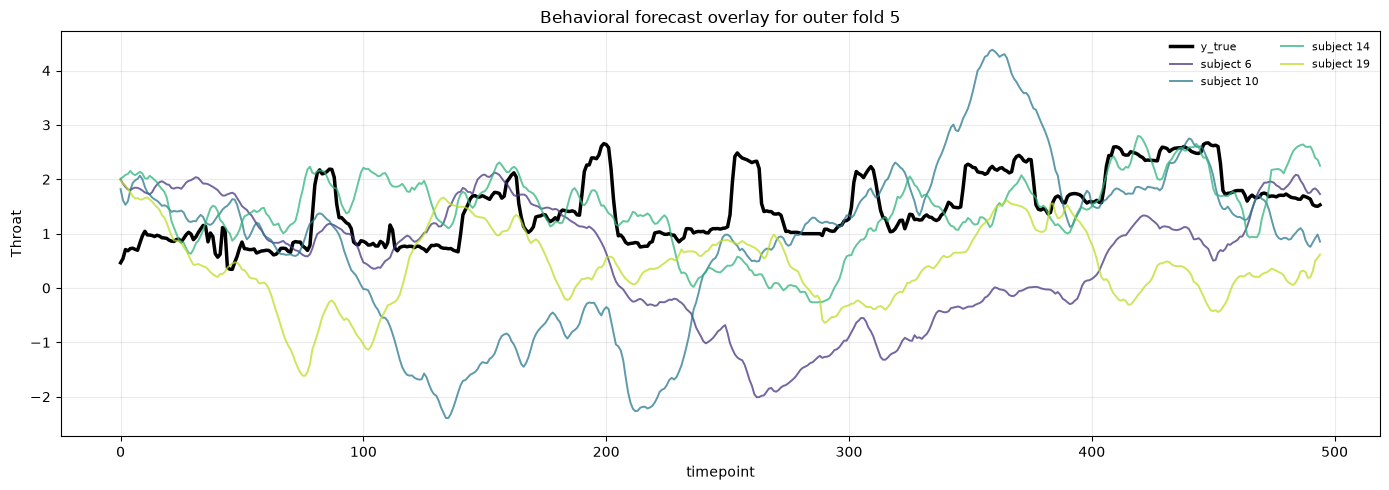

Subject overlay plot saved to: hyperopt-search/AfterTheRain_Throat_outerfold05_2026-06-13_10h46a/outer_fold_05/outer_fold_05_subject_overlay.png


In [ ]:
import matplotlib.pyplot as plt

if "final_predictions" not in globals():
    raise RuntimeError("Run the nested CV cell first so final_predictions is available.")

fig, ax = plt.subplots(figsize=(14, 5))
x_axis = np.arange(len(y_true_single))
ax.plot(x_axis, y_true_single, color="black", linewidth=2.5, label="y_true")

color_map = plt.cm.viridis(np.linspace(0.15, 0.9, len(final_predictions))) if len(final_predictions) > 1 else [plt.cm.viridis(0.55)]
for subject_index, y_pred in enumerate(final_predictions):
    subject_label = f"subject {test_subject_ids[subject_index]}"
    ax.plot(x_axis, y_pred.ravel(), color=color_map[subject_index], alpha=0.75, linewidth=1.4, label=subject_label)

ax.set_title(f"Behavioral forecast overlay for outer fold {outer_fold_index}")
ax.set_xlabel("timepoint")
ax.set_ylabel(target_column)
ax.legend(ncol=2, fontsize=8, frameon=False)
ax.grid(alpha=0.25)
fig.tight_layout()

subject_plot_path = fold_experiment_dir / f"outer_fold_{outer_fold_index:02d}_subject_overlay.png"
fig.savefig(subject_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Subject overlay plot saved to: {subject_plot_path}")